In [259]:
# importing required libraries
import numpy as np
import pandas as pd

import os
import sys

#importing current dataset
path=r"/home/dreams/Projects/webScraping/MachineLearningProject/IntroductionMachineLearning/dataset/ExamScorePrediction/Exam_Score_Prediction.csv"
dataset=pd.read_csv(path)

#creating dataFrame
df=pd.DataFrame(dataset)

## defining filtersfor dividing current dataFrame to two dataFrame(categoricalDf,numericalDf)
#defining filter_ to create categoricalDf
filter_=df.columns[df.dtypes=='object']

#creating categoricalDf dataFrame
categoricalDf=df[filter_]
categoricalDf=categoricalDf.astype('object')
#print(categoricalDf)

#defining filter_ for creating numericalDf
filter_=df.columns[(df.dtypes==np.int64)|(df.dtypes==np.float64)]
numericalDf=df[filter_]
numericalDf=numericalDf.drop(['student_id'],axis=1)
numericalDf=numericalDf.astype(np.int64)
# print(numericalDf)

In [260]:
import numpy as np
import pandas as pd 

from collections import Counter

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

# defining imputation functions(mean Imputation ,mode Imputation)
def meanImputation(df:pd.Series)->pd.Series:
    try:
        meanValue=np.nanmean(df)
        df=np.where(df.isna(),meanValue,df) #return np.ndarray object
        print('completed Mean Imputation')

        return df

    except ValueError:
        raise Exception ('It gotta problem with your ARRAY SHAPE')
    
    except Exception as e:
        return '{}'.format(e)


def modeImputation(df:pd.Series)->pd.Series:
    try:

        #filtering non-None valueCounts
        mask=[data for data in df if data is not(np.nan and None)]

        #remove None Values
        modeValue=Counter(mask).most_common(1)[0][0]

        #revising current with imputed data 
        # array_=np.array([x if x is not None else modeValue for x in mask],index=[idx for idx in df.index],dtype=object)
        df=pd.Series([x if x is not(np.nan and None) else modeValue for x in mask],dtype=object)

        print("Mode imputation is completed")

        return df
    
    except ValueError:
        raise Exception('It gotta problem with your ARRAY SHAPE')
    except Exception as e:
        return '{}'.format(e)

#rename columns course abbr to gull name
def toCourseFullName(df:pd.Series)->None:
    toFullName={
        'b.tech':'bioTechnology',
        'diploma':'diploma',
        'bba':'computerScience',
        'b.com':'computerEngineering',
        'b.sc':'electiricEngineering',
        'ba':'electronicEngineering',
        'bca':'bioEngineering'
    }

    categories=df.unique()
    # print(categories)

    for category in categories:
        # print(category)
        #print(toFullName[category])
        mask= (df==category)
        #print(mask)
        df.loc[mask]=toFullName[category]

    print("converted all abbr to full name")

# encoding all categorical Features
def encoding(df:pd.DataFrame):

    #defining features
    ordinalFeatures=['internet_access','sleep_quality','facility_rating','exam_difficulty']
    nominalFeatures=['gender','study_method','exam_score']

    #defining OrdinalEncoder object and OneHotEncoder object
    orEncoder=OrdinalEncoder()
    # nomEncoder=OneHotEncoder(sparse_output=False)
    labelEncoder=labelEncoder()

    # transform all featureSelection
    ct=ColumnTransformer(
        transformers=[
            ('labelEnc',labelEncoder,categoricalDf.columns)
            
           
        ]
    )
    ct.set_output(transform='pandas')
    df=ct.fit_transform(df)
    df=df.astype(np.int64)

    return df

# categoricalDf
# numericalDf

# implementing defined imputation techniques
for category in categoricalDf.columns:
    # categoricalDf.loc[:,category]=modeImputation(categoricalDf.loc[:,category])
    # currColumn=cateogoric
    categoricalDf.loc[:,category]=modeImputation(categoricalDf.loc[:,category])

out=all(categoricalDf.isna()==False)    
    # print(categoricalDf.loc[category])
# categoricalDf
for category in numericalDf.columns:
    numericalDf.loc[:,category]=meanImputation(numericalDf.loc[:,category])
    # numericalDf[category]=meanImputation(numericalDf[category])

out1=all(numericalDf.isna()==False)

print(out)
print(out1)





Mode imputation is completed
Mode imputation is completed
Mode imputation is completed
Mode imputation is completed
Mode imputation is completed
Mode imputation is completed
Mode imputation is completed
completed Mean Imputation
completed Mean Imputation
completed Mean Imputation
completed Mean Imputation
completed Mean Imputation
True
True


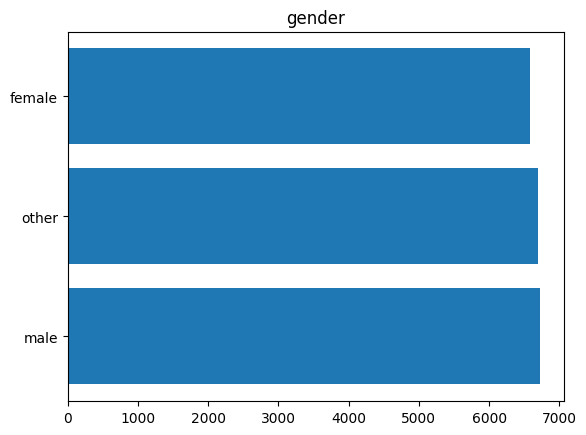

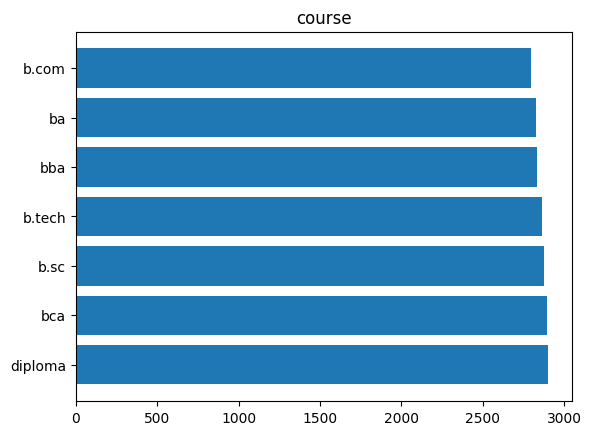

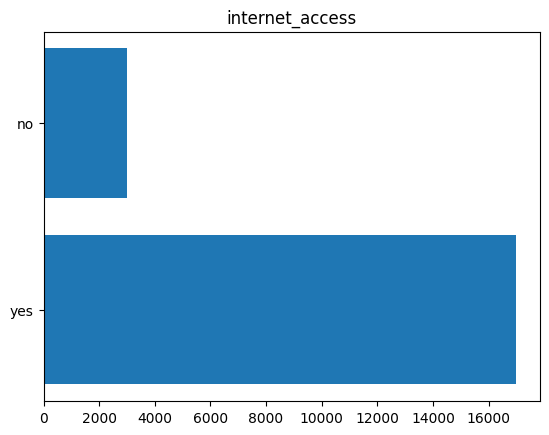

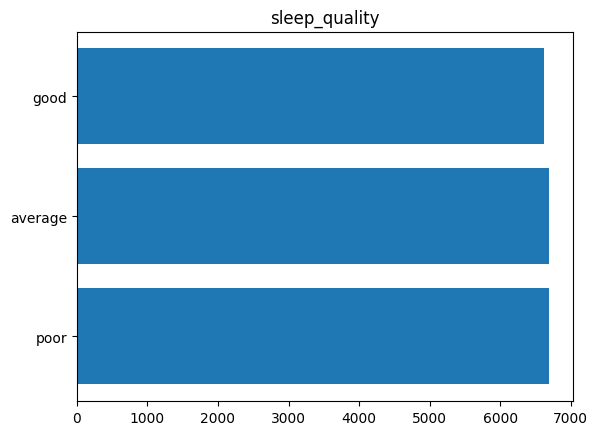

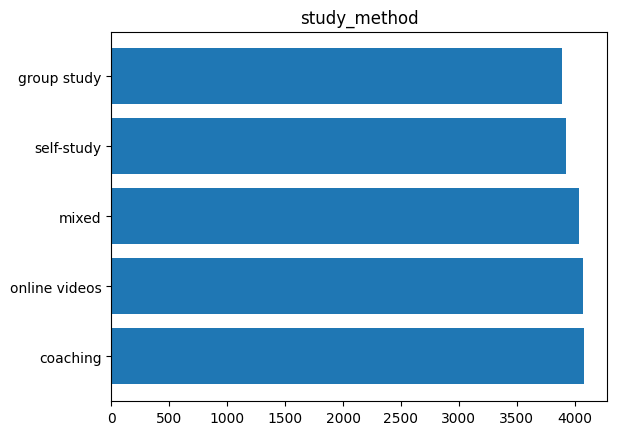

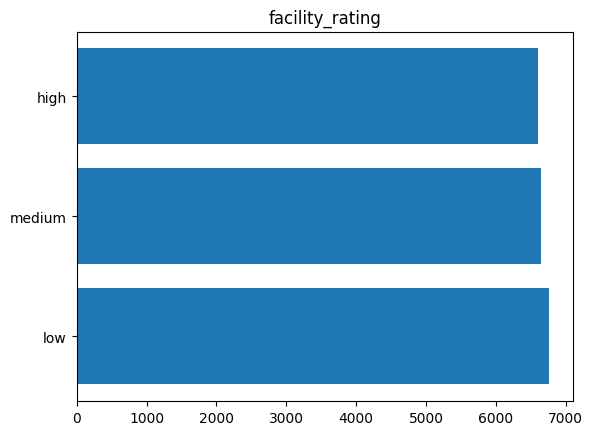

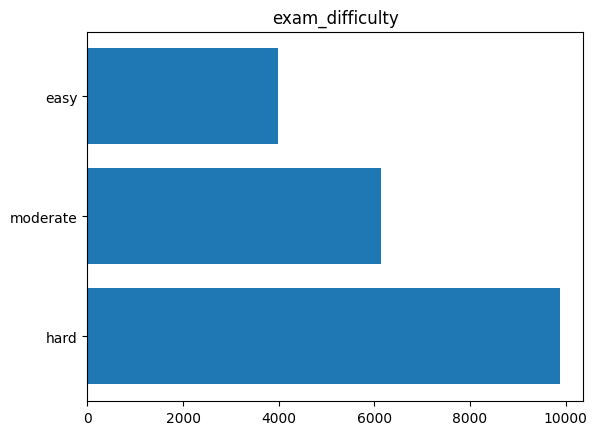

In [261]:
# data visualization for categorical features
%matplotlib inline
import matplotlib.pyplot as plt 
import seaborn as sns

for categorical in categoricalDf.columns:
    #creating barh and return total of categorical features
    valueCounts=categoricalDf[categorical].T.value_counts()
    #print(valueCounts)
    plt.barh(categoricalDf[categorical].T.unique(),valueCounts)
    plt.title(categorical)
    plt.show()


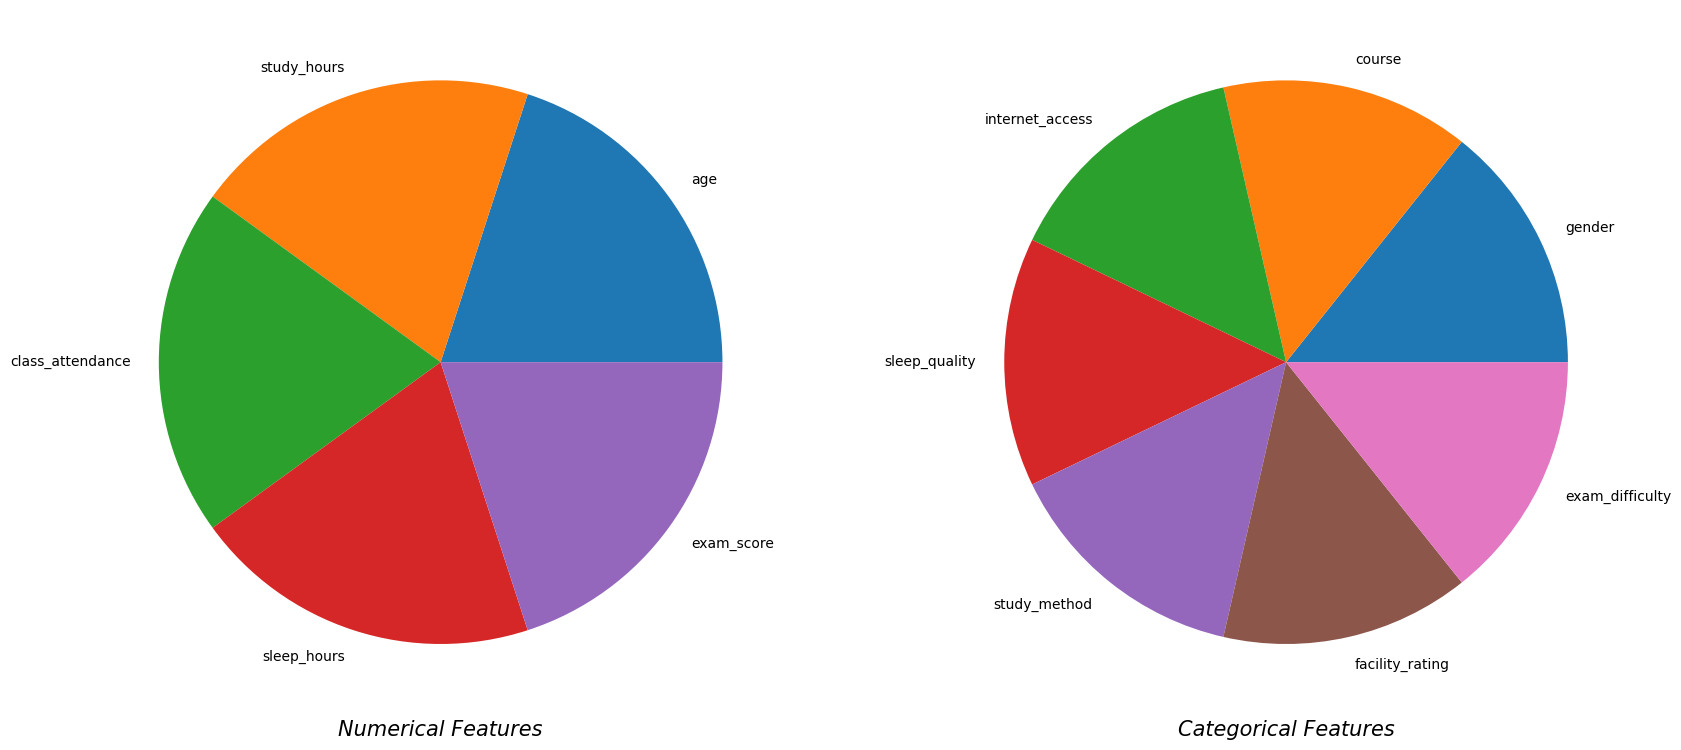

In [262]:
##creating pie charts for categorical and numerical features
#importing required libraries
%matplotlib inline
import matplotlib.pyplot as plt
# defining constants
FONT={
    'color':'black',
    'size':'15',
    'style':'oblique'
}

fig,axes=plt.subplots(1,2,sharex=False,sharey=False,figsize=(20,20))
ax1,ax2=axes.flatten()

numericalDf.count().plot.pie(ax=ax1)
categoricalDf.count().plot.pie(ax=ax2)

ax1.set_xlabel('Numerical Features',fontdict=FONT)
ax2.set_xlabel('Categorical Features',fontdict=FONT)

plt.show()

In [263]:
#doing chi-square test 
from scipy.stats import chi2_contingency
import pandas as pd

#defining constants
df=pd.DataFrame()
ALPHA=0.05

#course feature do chi-square test for each categorical features(except course features)
for column in categoricalDf.columns:
    _,p,_,_=chi2_contingency(
        pd.crosstab(
            categoricalDf['course'],categoricalDf[column]
        ))
    if ALPHA<p:
        print(f"{column}:/t The two variables are independent(there is no association between them).rejected")
    else:
        print(f'{column}:/t The two variables are dependent(there is an association between them).Accepted')
    df2=pd.DataFrame(data={column:[p]},dtype=object)
    df=pd.concat([df,df2],axis=1)


gender:/t The two variables are dependent(there is an association between them).Accepted
course:/t The two variables are dependent(there is an association between them).Accepted
internet_access:/t The two variables are independent(there is no association between them).rejected
sleep_quality:/t The two variables are independent(there is no association between them).rejected
study_method:/t The two variables are independent(there is no association between them).rejected
facility_rating:/t The two variables are independent(there is no association between them).rejected
exam_difficulty:/t The two variables are independent(there is no association between them).rejected


In [264]:
# #encoding categorical features
# importing required libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
#defining constants
ORDINALFEATURES=['internet_access','sleep_quality','facility_rating','exam_difficulty']
NOMINALFEATURES=['gender','course','study_method']

def encoding(df:pd.DataFrame)->pd.DataFrame:
    # #unpack features parameter
    # ordinal,nominal=features
    ###print(ordinal,nominal)
    
    #defining encoder
    orEncoder=OrdinalEncoder()
    nomEncoder=OneHotEncoder(sparse_output=False)

    ct=ColumnTransformer(
       transformers=[('ord',orEncoder,ORDINALFEATURES),
        ('oneHot',nomEncoder,NOMINALFEATURES)]
    )

    ct.set_output(transform='pandas')
    df=ct.fit_transform(df)
    df=df.astype(np.int64)

    return df

categoricalDf=encoding(categoricalDf)

<Axes: >

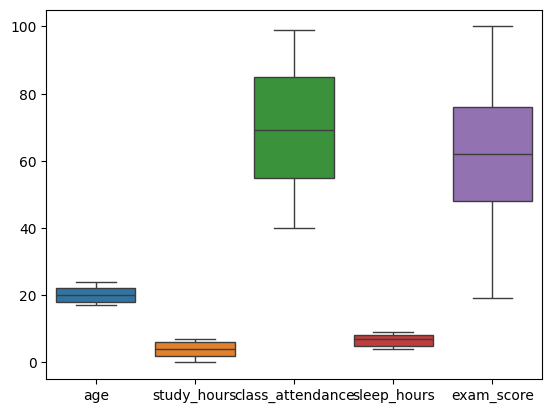

In [265]:
###data visualizing for  numerical Features
#creating boxplot for numerical Features
# importing required libraries
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(numericalDf)

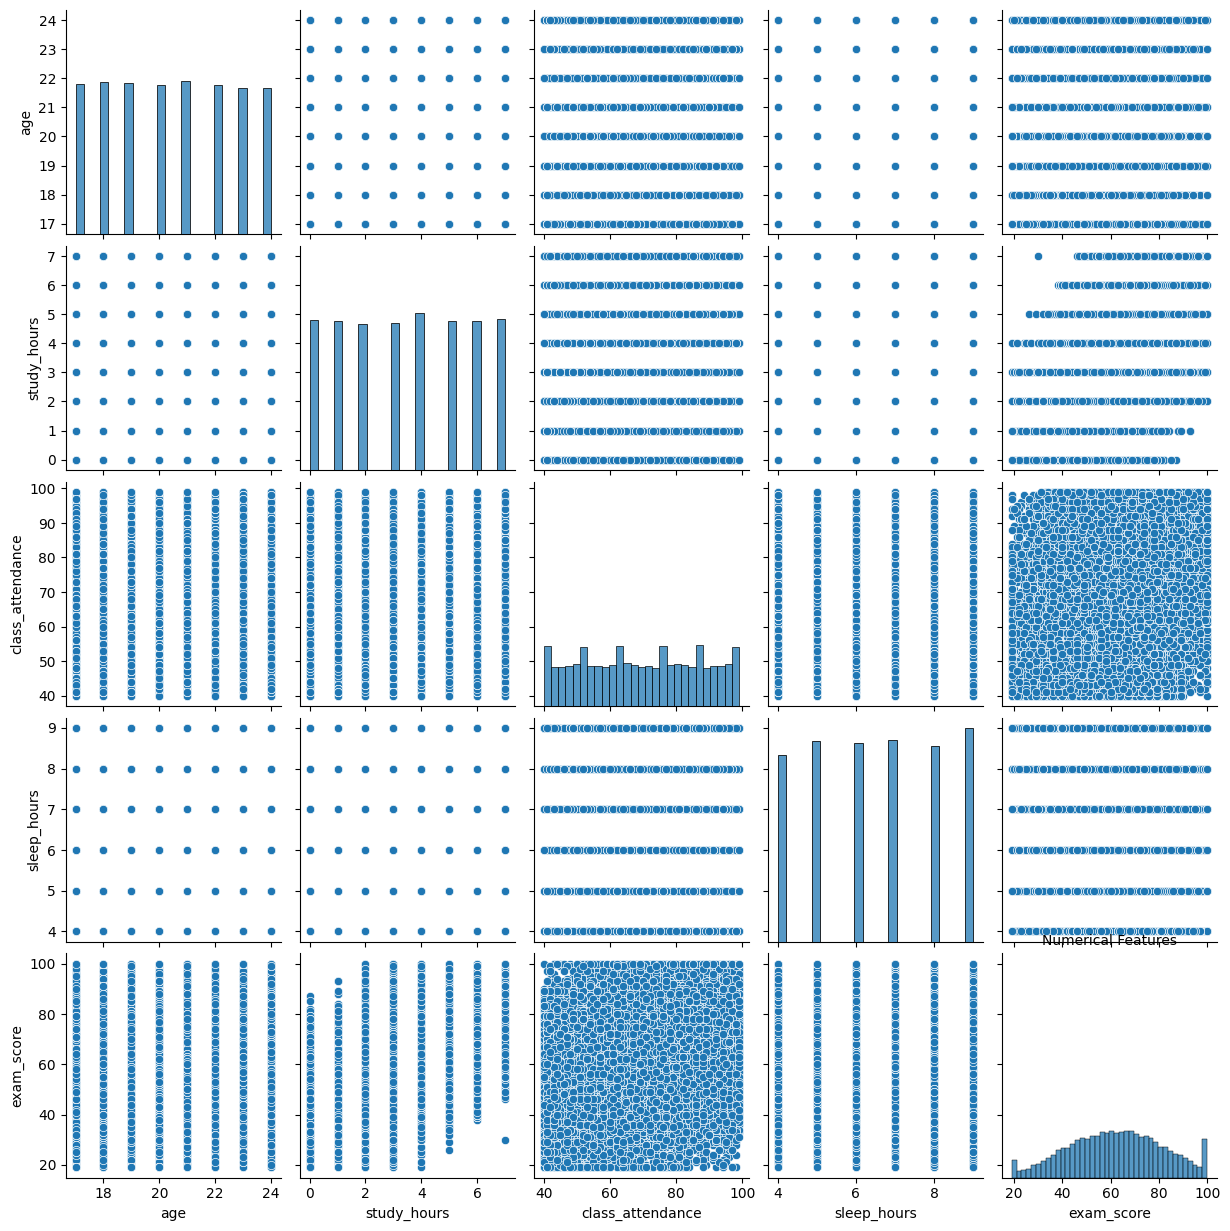

In [266]:
#creating pairplot for numerical features
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(numericalDf)
plt.title(
        'Numerical Features',
        fontdict={
            'font':'Sans Serif',
        })
plt.show()


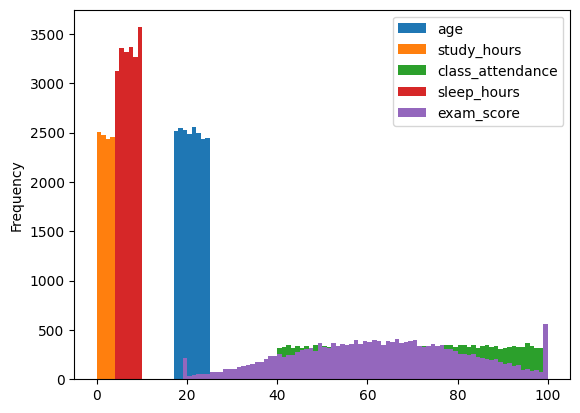

In [267]:
%matplotlib inline
import matplotlib.pyplot as plt

numericalDf.plot.hist(bins=100)
plt.show()



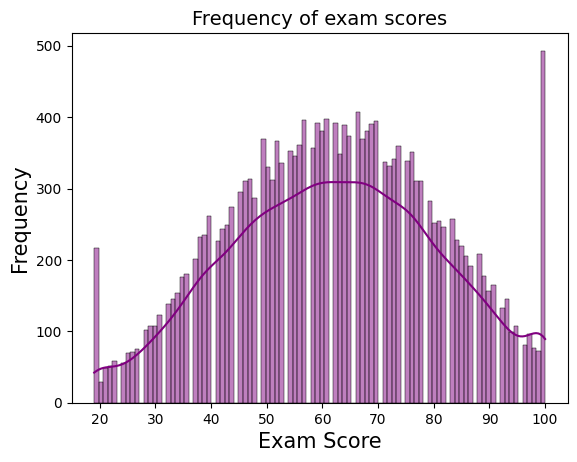

In [268]:
##creating Possion distribution with sns.histplot()
#importing requried libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['exam_score'],bins=100,color='purple',kde=True)

#revising axes
plt.title('Frequency of exam scores',fontsize=14)
plt.xlabel('Exam Score',fontsize=15)
plt.ylabel('Frequency',fontsize=15)

plt.show()
#Poisson distribution



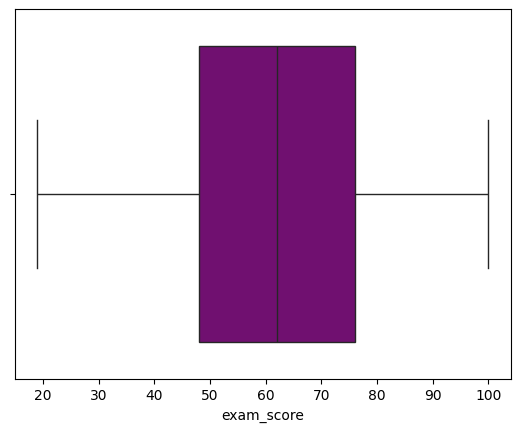

In [269]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['exam_score'],color='purple')
plt.show()

<Axes: xlabel='study_hours', ylabel='Count'>

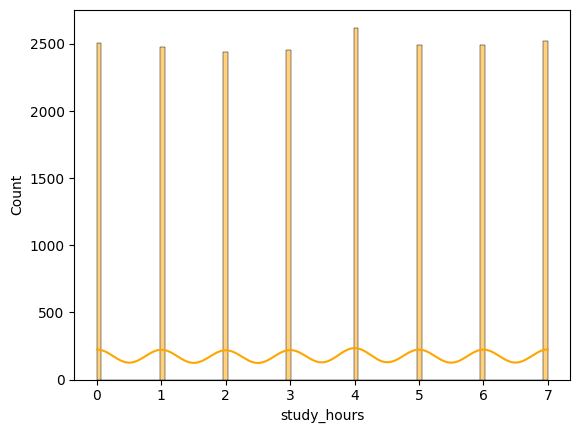

In [270]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['study_hours'],kde=True,bins=100,color='orange')

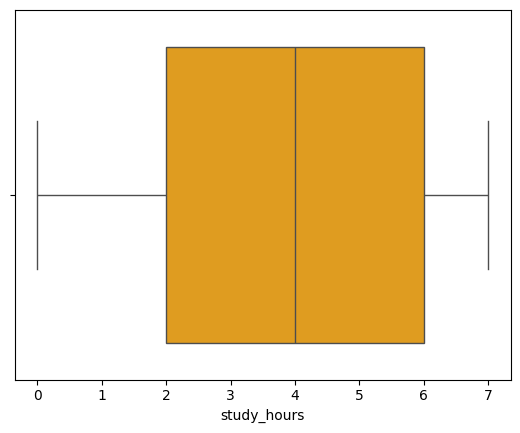

In [271]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['study_hours'],color='orange')
plt.show()

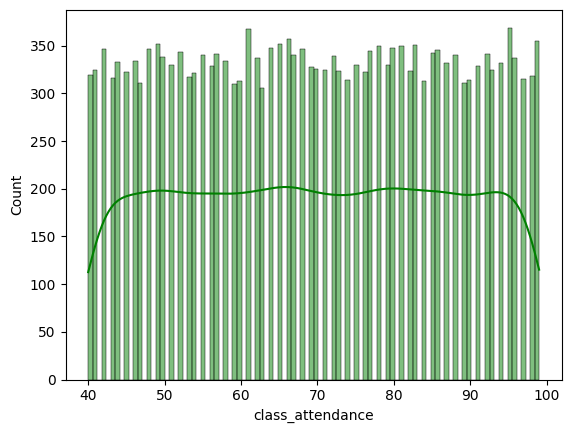

In [272]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['class_attendance'],bins=100,kde=True,color='green')
plt.show()

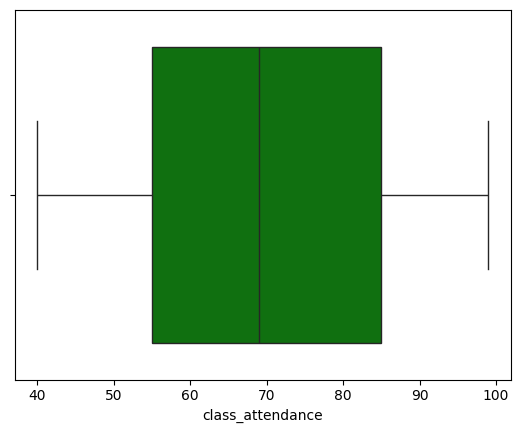

In [273]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['class_attendance'],color='green')
plt.show()

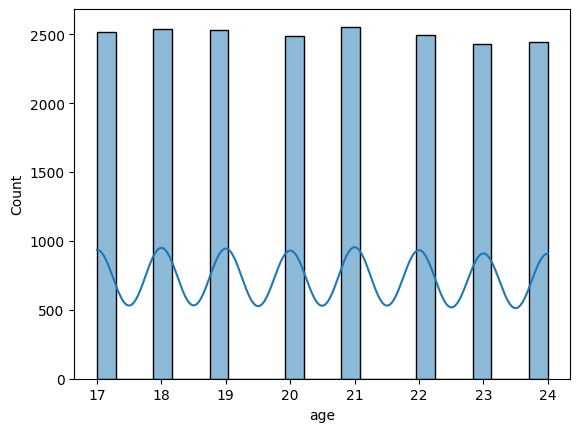

In [274]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['age'],kde=True)
plt.show()

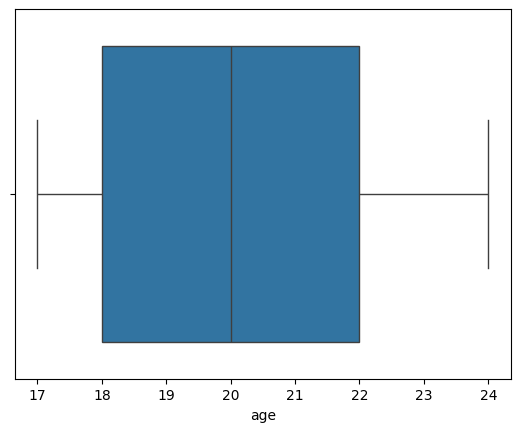

In [275]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['age'])
plt.show()

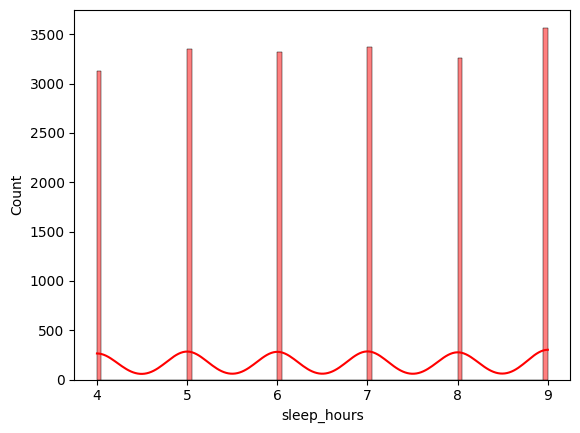

In [276]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['sleep_hours'],bins=100,kde=True,color='red')
plt.show()



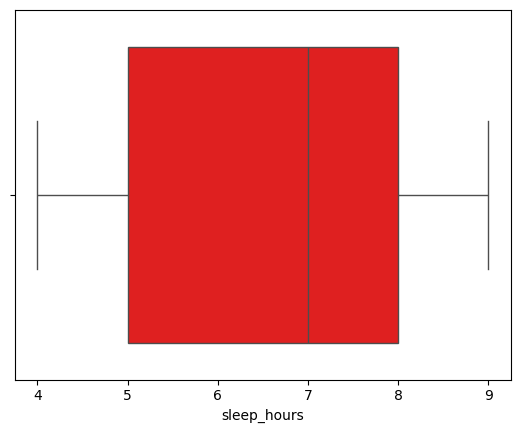

In [277]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['sleep_hours'],color='red')
plt.show()

In [278]:
###normalize numerical features
#importing required libraries
import pandas as pd
import numpy as np

from typing import List

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler #Z-score
from sklearn.preprocessing import PowerTransformer

# function declaration
def dataNormalization(df:pd.DataFrame,features:List[str],*normalization:List)->None:
    """
        df:pd.DataFrame
        normalization:sklearn.preprocessing returns normalization objects
        features:str returns column names

        return None
    """
    pt,minmax=normalization
    #function definition
    for feature in features:
        df.loc[:,feature]=pt.fit_transform(df.loc[:,feature].values.reshape(-1,1))
        df.loc[:,feature]=minmax.fit_transform(df.loc[:,feature].values.reshape(-1,1))


#function calling
FEATURES=numericalDf.columns
# NORMALIZATION=[PowerTransformer,MinMaxScaler]
dataNormalization(numericalDf,FEATURES,PowerTransformer(),MinMaxScaler())
# numericalDf.head()

/tmp/ipykernel_6343/1625863263.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.54605809  1.10151722  0.67799644 ... -0.63328636 -0.63328636
 -0.18897938]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,feature]=pt.fit_transform(df.loc[:,feature].values.reshape(-1,1))
/tmp/ipykernel_6343/1625863263.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.59271373 -0.14159371  1.42547203 ...  1.42547203  0.27953325
  1.42547203]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,feature]=pt.fit_transform(df.loc[:,feature].values.reshape(-1,1))
/tmp/ipykernel_6343/1625863263.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.27569397 -0.29235278  0.39668533 ... -0.

In [279]:
# importing required libraries
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet,Lasso
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


#enteredselected features
selectedNumericalFeatures=['study_hours','class_attendance','sleep_hours']

#defining mask
mask=categoricalDf.columns.str.startswith('oneHotTarget')
# print(mask)
selectedCategoricalFeatures=categoricalDf[categoricalDf.columns[~mask]]


# X=numericalDf[selectedNumericalFeatures].values.reshape(-1,1)
# y=categoricalDf[mask].values.reshape(-1,1)
# print(selectedCategoricalFeatures)

# X_train,X_test,Y_train,Y_test=train_test_split(X,y,random_state=42,test_size=0.33)

# print('Train:\t{}\t{}'.format(X_train.shape,Y_train.shape))
# print("Test:\t{}\t{}".format(X_test.shape,Y_test.shape))
# print(y)

In [280]:
from sklearn.linear_model import LogisticRegression
model1=make_pipeline(
    ElasticNet()
)
selectedNumericalFeatures=['study_hours','class_attendance','sleep_hours']
X=numericalDf[selectedNumericalFeatures]
y=numericalDf['exam_score']
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.33,random_state=42)
model1.fit(X_train,Y_train)





,steps,"[('elasticnet', ...)]"
,transform_input,None
,memory,None
,verbose,False
,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001


In [281]:
categoricalDf

,ord__internet_access,ord__sleep_quality,ord__facility_rating,ord__exam_difficulty,oneHot__gender_female,oneHot__gender_male,oneHot__gender_other,oneHot__course_b.com,oneHot__course_b.sc,oneHot__course_b.tech,oneHot__course_ba,oneHot__course_bba,oneHot__course_bca,oneHot__course_diploma,oneHot__study_method_coaching,oneHot__study_method_group study,oneHot__study_method_mixed,oneHot__study_method_online videos,oneHot__study_method_self-study
0,1,2,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0
1,1,0,2,2,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
2,1,2,0,2,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0
3,1,0,1,2,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
4,1,2,1,2,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
19996,0,0,2,2,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0
19997,1,2,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0
19998,0,1,2,2,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1


In [286]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet,Lasso
from sklearn.multiclass import  OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


selectedNumericalFeatures=['study_hours','class_attendance','sleep_hours']
filter_=categoricalDf.columns.str.startswith('oneHot')
selectedCategoricalFeature=categoricalDf[categoricalDf.columns[~filter_]]
X=numericalDf[selectedNumericalFeatures]+selectedCategoricalFeature
X=X.fillna(0)
y=categoricalDf[categoricalDf.columns[~filter_]]

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y,random_state=42,test_size=0.33)


from sklearn.linear_model import LogisticRegression
model=make_pipeline(
    LogisticRegression(penalty='elasticnet',solver='saga',l1_ratio=0.5)
) ##classsification report precision:0.14 i have tried all solvers and penalties


In [283]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
model.fit(X_train,Y_train)
pred=model.predict(X_test)
print(classification_report(Y_test,pred))
print(confusion_matrix(Y_test,pred))
print(accuracy_score(Y_test,pred))

ValueError: y should be a 1d array, got an array of shape (13400, 4) instead.